# Tokenizador n grama

In [66]:
import torch

In [67]:
# Obra de lovecraft em português
input_file = "data/lovecraft_ptbr_clean.txt"
print(f"{input_file=}")
with open(input_file, "r", encoding="utf-8") as f:
    text = f.read()
chars = sorted(list(set(text)))
print(f"{len(text)=}")
chars = sorted(list(set(text)))
print(f"{chars=}")
vocab_size = len(chars)
print(f"{vocab_size=}")
estimated_starting_loss = -torch.log(torch.ones(1) / vocab_size).item()
print(f"{estimated_starting_loss=}")
# create a mapping from characters to integers
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}
# encoder: take a string, output a list of integers
encode = lambda s: [stoi[c] for c in s]
# decoder: take a list of integers, output a string
decode = lambda l: "".join([itos[i] for i in l])
assert decode(encode("hello world")) == "hello world"
print(f"{stoi=}")
print(f"{itos=}")

input_file='data/lovecraft_ptbr_clean.txt'
len(text)=728206
chars=['\n', ' ', '!', '"', "'", '(', ')', ',', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
vocab_size=49
estimated_starting_loss=3.8918204307556152
stoi={'\n': 0, ' ': 1, '!': 2, '"': 3, "'": 4, '(': 5, ')': 6, ',': 7, '-': 8, '.': 9, '0': 10, '1': 11, '2': 12, '3': 13, '4': 14, '5': 15, '6': 16, '7': 17, '8': 18, '9': 19, ':': 20, ';': 21, '?': 22, 'a': 23, 'b': 24, 'c': 25, 'd': 26, 'e': 27, 'f': 28, 'g': 29, 'h': 30, 'i': 31, 'j': 32, 'k': 33, 'l': 34, 'm': 35, 'n': 36, 'o': 37, 'p': 38, 'q': 39, 'r': 40, 's': 41, 't': 42, 'u': 43, 'v': 44, 'w': 45, 'x': 46, 'y': 47, 'z': 48}
itos={0: '\n', 1: ' ', 2: '!', 3: '"', 4: "'", 5: '(', 6: ')', 7: ',', 8: '-', 9: '.', 10: '0', 11: '1', 12: '2', 13: '3', 14: '4', 15: '5', 16: '6', 17: '7', 18: '8', 19: '9', 20: ':', 21: ';

In [68]:
text_sample = text[:100]
text_sample

'dagon\n escrevo esta historia sob uma pressao mental consideravel, uma vez que hoje a noite me apago.'

In [69]:
def ngrams(word, n_gram = 2):
    n_odd_chars = len(word) % n_gram
    if n_odd_chars > 0:
        pad = n_gram - n_odd_chars
        word += " " * pad
    n_gram_list = [word[i:i+n_gram] for i in range(0, len(word), n_gram)]
    return n_gram_list

ngrams("dagonia")

['da', 'go', 'ni', 'a ']

In [70]:
import re

def tokenize(text_sample):
    new_string = re.sub("(\s)", '\\1[cut]',  text_sample)
    words = new_string.split('[cut]')
    # words = text_sample.split()
    words = [w for w in words if w != "" and w != " "]
    words = [re.sub(" +$", " ", re.sub("$", " ", w)) for w in words]
    # print(words)
    n_grams_list = []
    for w in words:
        n_grams_list.extend(ngrams(w))
    n_grams_list
    return n_grams_list

tokenize(text_sample)[:13]

['da', 'go', 'n ', '\n ', 'es', 'cr', 'ev', 'o ', 'es', 'ta', '  ', 'hi', 'st']

In [71]:
tokens = tokenize(text_sample)
def detokenize(n_grams_list):
    text = "".join(n_grams_list)
    return re.sub(" +", " ", text)
display(text_sample)
text_clean = detokenize(tokenize(text_sample))
display(text_clean)
display(detokenize(tokenize(text_clean)))
text_clean = detokenize(tokenize(text_sample))
assert text_clean == detokenize(tokenize(text_clean))

'dagon\n escrevo esta historia sob uma pressao mental consideravel, uma vez que hoje a noite me apago.'

'dagon \n escrevo esta historia sob uma pressao mental consideravel, uma vez que hoje a noite me apago. '

'dagon \n escrevo esta historia sob uma pressao mental consideravel, uma vez que hoje a noite me apago. '

In [72]:
tokens = sorted(list(set(tokenize(text))))
print(f"{tokens[:12]=}")

vocab_size = len(tokens)
print(f"{vocab_size=}")
estimated_starting_loss = -torch.log(torch.ones(1) / vocab_size).item()
print(f"{estimated_starting_loss=}")

# create a mapping from characters to integers
stoi = {t: i for i, t in enumerate(tokens)}
itos = {i: t for i, t in enumerate(tokens)}
# encoder: take a string, output a list of integers
encode = lambda s: [stoi[c] for c in tokenize(s)]
# decoder: take a list of integers, output a string
decode = lambda l: detokenize([itos[i] for i in l])
assert decode(encode("ola mundo ")) == "ola mundo "
print(f"{stoi=}")
print(f"{itos=}")

tokens[:12]=['\n ', ' \n', '  ', '! ', '!"', '" ', '",', '".', '"1', '";', '"a', '"b']
vocab_size=751
estimated_starting_loss=6.621405601501465
stoi={'\n ': 0, ' \n': 1, '  ': 2, '! ': 3, '!"': 4, '" ': 5, '",': 6, '".': 7, '"1': 8, '";': 9, '"a': 10, '"b': 11, '"c': 12, '"d': 13, '"e': 14, '"f': 15, '"g': 16, '"h': 17, '"i': 18, '"j': 19, '"m': 20, '"n': 21, '"o': 22, '"p': 23, '"q': 24, '"r': 25, '"s': 26, '"t': 27, '"u': 28, '"v': 29, '"w': 30, '"y': 31, "' ": 32, "',": 33, "'.": 34, "'1": 35, "'a": 36, "'b": 37, "'e": 38, "'g": 39, "'h": 40, "'l": 41, "'n": 42, "'o": 43, "'p": 44, "'s": 45, "'u": 46, "'y": 47, '(a': 48, '(d': 49, '(e': 50, '(f': 51, '(l': 52, '(m': 53, '(n': 54, '(q': 55, '(s': 56, '(w': 57, ') ': 58, '),': 59, ').': 60, ', ': 61, '--': 62, '-1': 63, '-3': 64, '-5': 65, '-7': 66, '-8': 67, '-a': 68, '-b': 69, '-c': 70, '-d': 71, '-e': 72, '-f': 73, '-h': 74, '-i': 75, '-l': 76, '-m': 77, '-n': 78, '-o': 79, '-p': 80, '-r': 81, '-s': 82, '-t': 83, '-v': 84, '-y': 85

# Tiktoken

In [73]:
path_input ="data/lovecraft_ptbr_clean.txt"
print("load_data...")
with open(path_input, "r", encoding="utf-8") as f:
    text = f.read()
print(f"{text[:2_000]=}")
print(f"{len(text)=}")

load_data...
text[:2_000]='dagon\n escrevo esta historia sob uma pressao mental consideravel, uma vez que hoje a noite me apago. sem dinheiro, com o estoque da droga que torna a vida suportavel proximo do fim, nao aguento mais essa tortura; estou prestes a me atirar pela janela da agua-furtada na desolacao da rua la embaixo. nao entenda minha dependencia da morfina como uma fraqueza ou uma perversao. quando o senhor ler estas paginas rabiscadas as pressas podera entender, ainda que nao por completo, a minha ansia pelo esquecimento ou pela morte.\n foi numa das regioes mais abertas e menos frequentadas do enorme pacifico que o paquete em que eu era supercargo caiu vitima das forcas alemas. era o inicio da grande guerra, e as forcas oceanicas dos teutos ainda nao haviam afundado ao nivel da degradacao posterior; de modo que nossa embarcacao foi capturada como um trofeu legitimo, enquanto nos, da tripulacao, fomos tratados com toda a justeza e consideracao devidas aos prisioneiros navais.

In [74]:
import tiktoken
enc = tiktoken.get_encoding("cl100k_base") # GPT-4 tokenizer
print(enc.encode("안녕하세요 👋 (hello in Korean!)"))
print(enc.decode(enc.encode("안녕하세요 👋 (hello in Korean!)")) == "안녕하세요 👋 (hello in Korean!)")
# match the above for your own tokenizer, and also implement a train() function

[31495, 230, 75265, 243, 92245, 62904, 233, 320, 15339, 304, 16526, 16715]
True


In [75]:
from tiktoken._educational import SimpleBytePairEncoding

# Train a BPE tokeniser on a small amount of text
gpt2_pattern = r"(\S+|[^\S\n]+|\n)"

enc = SimpleBytePairEncoding.train(text, vocab_size=600, pat_str=gpt2_pattern)

print("This is the sequence of merges performed in order to encode 'hello world':")
tokens = enc.encode("hello world")

The current most common pair is b'e' + b's'
So we made b'es' our 257th token
Now the first fifty words in our training data look like:
dagon
 escrevo esta historia sob uma pressao mental consideravel, uma vez que hoje a noite me apago. sem dinheiro, com o estoque da droga que


The current most common pair is b'a' + b's'
So we made b'as' our 258th token
Now the first fifty words in our training data look like:
dagon
 escrevo esta historia sob uma pressao mental consideravel, uma vez que hoje a noite me apago. sem dinheiro, com o estoque da droga que


The current most common pair is b'o' + b's'
So we made b'os' our 259th token
Now the first fifty words in our training data look like:
dagon
 escrevo esta historia sob uma pressao mental consideravel, uma vez que hoje a noite me apago. sem dinheiro, com o estoque da droga que


The current most common pair is b'd' + b'e'
So we made b'de' our 260th token
Now the first fifty words in our training data look like:
dagon
 escrevo esta historia

KeyboardInterrupt: 

In [ ]:
import joblib

joblib.dump(enc, "artifacts/tokenizer_simple_bpe.joblib")

['artifacts/tokenizer_simple_bpe.joblib']

In [ ]:
joblib.load("artifacts/tokenizer_simple_bpe.joblib")
enc = joblib.load("artifacts/tokenizer_simple_bpe.joblib")
print(enc.decode(tokens) == "hello world")


True


# Lovecraft 2.0

In [ ]:
path_zips = "data/site_lovecraft"
from pathlib import Path

In [ ]:
import zipfile

zip_files = list(Path(path_zips).glob("*.zip"))

for file in zip_files:
    with zipfile.ZipFile(file, "r") as zip_ref:
        zip_ref.extractall(path_zips)

In [ ]:
from pathlib import Path
hss = []

# change to extract only the main text, excluding footnotes, headers, and other non-text elements
pdf_files = list(Path(path_zips).glob("*.pdf"))
txt_files = []
for file in pdf_files:
    print(file)
    import pdfplumber
    hs = []
    with pdfplumber.open(file) as pdf:
        text = ""
        
        # for page in pdf.pages:
        #     text += page.extract_text()
        for page in pdf.pages:
            # print("NEW PAGE")
            last_top = 0
            # Extract text from the page by font size
            for element in page.extract_words():
                # print(element)
                hs.append(round(element["height"], 2))
                if element["top"] - last_top > 14:  # Check for line breaks
                    text += "\n"
                    # print(f"Line break")
                if round(element["height"], 2) >= 11.60:
                    text += element["text"] + " "
                last_top = element["top"]
    hss.append(hs)
    txt_file = file.with_suffix(".txt")
    with open(txt_file, "w", encoding="utf-8") as f:
        f.write(text.strip())
    txt_files.append(txt_file)

txt_files

data\site_lovecraft\alquimista.pdf
data\site_lovecraft\armadilha.pdf
data\site_lovecraft\arvore.pdf
data\site_lovecraft\astrophobos.pdf
data\site_lovecraft\carta.pdf
data\site_lovecraft\catacumba.pdf
data\site_lovecraft\celephais.pdf
data\site_lovecraft\chamado.pdf
data\site_lovecraft\desafio.pdf
data\site_lovecraft\desespero.pdf
data\site_lovecraft\diario.pdf
data\site_lovecraft\doalem.pdf
data\site_lovecraft\dunwich.pdf
data\site_lovecraft\executor.pdf
data\site_lovecraft\forasteiro.pdf
data\site_lovecraft\gatos.pdf
data\site_lovecraft\historia.pdf
data\site_lovecraft\hypnos.pdf
data\site_lovecraft\jardim.pdf
data\site_lovecraft\klarkash.pdf
data\site_lovecraft\livro.pdf
data\site_lovecraft\martin.pdf
data\site_lovecraft\morte.pdf
data\site_lovecraft\museu.pdf
data\site_lovecraft\musica.pdf
data\site_lovecraft\natal.pdf
data\site_lovecraft\navio.pdf
data\site_lovecraft\nemesis.pdf
data\site_lovecraft\noivadomar.pdf
data\site_lovecraft\notas.pdf
data\site_lovecraft\oceano.pdf
data\sit

[WindowsPath('data/site_lovecraft/alquimista.txt'),
 WindowsPath('data/site_lovecraft/armadilha.txt'),
 WindowsPath('data/site_lovecraft/arvore.txt'),
 WindowsPath('data/site_lovecraft/astrophobos.txt'),
 WindowsPath('data/site_lovecraft/carta.txt'),
 WindowsPath('data/site_lovecraft/catacumba.txt'),
 WindowsPath('data/site_lovecraft/celephais.txt'),
 WindowsPath('data/site_lovecraft/chamado.txt'),
 WindowsPath('data/site_lovecraft/desafio.txt'),
 WindowsPath('data/site_lovecraft/desespero.txt'),
 WindowsPath('data/site_lovecraft/diario.txt'),
 WindowsPath('data/site_lovecraft/doalem.txt'),
 WindowsPath('data/site_lovecraft/dunwich.txt'),
 WindowsPath('data/site_lovecraft/executor.txt'),
 WindowsPath('data/site_lovecraft/forasteiro.txt'),
 WindowsPath('data/site_lovecraft/gatos.txt'),
 WindowsPath('data/site_lovecraft/historia.txt'),
 WindowsPath('data/site_lovecraft/hypnos.txt'),
 WindowsPath('data/site_lovecraft/jardim.txt'),
 WindowsPath('data/site_lovecraft/klarkash.txt'),
 Windows

In [ ]:
import pandas as pd

countss = []
for i, (hs, file) in enumerate(zip(hss, pdf_files)):
    counts = pd.Series(hs).round(4).value_counts().sort_index(ascending=False)
    print(file)
    print(counts)
    print()


data\site_lovecraft\alquimista.pdf
36.00       1
12.00    3600
11.04       4
9.96       90
Name: count, dtype: int64

data\site_lovecraft\armadilha.pdf
48.00       1
14.60       1
14.42       5
12.00    7717
9.96       67
6.48        5
Name: count, dtype: int64

data\site_lovecraft\arvore.pdf
20.25       2
15.00       7
14.31      14
12.00    1712
9.75      376
6.75       14
Name: count, dtype: int64

data\site_lovecraft\astrophobos.pdf
12.00    274
9.96      92
Name: count, dtype: int64

data\site_lovecraft\carta.pdf
12.00    363
10.02     70
Name: count, dtype: int64

data\site_lovecraft\catacumba.pdf
34.50       1
14.37       3
13.09       7
12.00    4148
10.02     373
6.48        3
Name: count, dtype: int64

data\site_lovecraft\celephais.pdf
34.50       1
13.09       4
12.00    2569
10.93       1
10.02      91
Name: count, dtype: int64

data\site_lovecraft\chamado.pdf
19.62        4
14.03       37
13.28        7
12.35        1
11.67        2
11.63      888
11.62    11410
10.92     

In [ ]:
texts = []
for file in txt_files:
    print(file)
    with open(file, "r", encoding="utf-8") as f:
        text = f.read()
    texts.append(text)

data\site_lovecraft\alquimista.txt
data\site_lovecraft\armadilha.txt
data\site_lovecraft\arvore.txt
data\site_lovecraft\astrophobos.txt
data\site_lovecraft\carta.txt
data\site_lovecraft\catacumba.txt
data\site_lovecraft\celephais.txt
data\site_lovecraft\chamado.txt
data\site_lovecraft\desafio.txt
data\site_lovecraft\desespero.txt
data\site_lovecraft\diario.txt
data\site_lovecraft\doalem.txt
data\site_lovecraft\dunwich.txt
data\site_lovecraft\executor.txt
data\site_lovecraft\forasteiro.txt
data\site_lovecraft\gatos.txt
data\site_lovecraft\historia.txt
data\site_lovecraft\hypnos.txt
data\site_lovecraft\jardim.txt
data\site_lovecraft\klarkash.txt
data\site_lovecraft\livro.txt
data\site_lovecraft\martin.txt
data\site_lovecraft\morte.txt
data\site_lovecraft\museu.txt
data\site_lovecraft\musica.txt
data\site_lovecraft\natal.txt
data\site_lovecraft\navio.txt
data\site_lovecraft\nemesis.txt
data\site_lovecraft\noivadomar.txt
data\site_lovecraft\notas.txt
data\site_lovecraft\oceano.txt
data\sit

In [ ]:
import re
remove_sentences = [
    "\d* ?www.sitelovecraft.com de3103@yahoo.com.br\n",
    "\d* ?www.sitelovecraft.com",
    "de3103@yahoo.com.br",

    "Quem é Renato S.*@arquivors.com",
    "Traduzido por Gaspar Garção.*nicolau19@yahoo.com",
    "Tradução: Lara D’Onofrio Longo",
    "Tradução: Mário Jorge Lailla Vargas",
    "Tradução: Renato Suttana",
    "Tradução: Gaspar Garção",
    "Tradução: Fábio Bettega",
    "Tradução: Nicolau Saião",
    "Quem é Lara.*ig.com.br",
    "Quem é Nicolau.*yahoo.com",
    "Escrito em Março de 1922.*Augusto Seoni de oliveira",
    "Escrito em 1920 .* 3-10",
    "Traduzido por Gaspar.*Nicolau Saião",
    "Fonte: “Os Fungos de Yuggoth”[.]",
    "Black Sun Editores",
    "Tradução: Leonardo Nunes Nunes, (auxiliado pelos amigos Luiz Poleto e Felipe)",
    "Tradução: Alessa Akechi",
    "Escrito por volta de 1934",
    "trad[.] (de )?KA-AK-KIM",
    "e Henry S. Whitehead ",
    "e William Lumley "

    " – C. L. Moore, A. Merritt, H. P. Lovecraft, Robert E. Howard e Frank Belknap Long.*Moore",
    "Este texto foi convertido em PDF.*",
    "Tradução: [a-zA-Z ]+\d?\n",
    "Fonte: [a-zA-Z ]+\d?\n",
    "por [hpHP .]+Lovecraft",
    "– [hpHP .]+Lovecraft",
    "- H. P. Lovecraft",
    "H.P. Lovecraft",
    "H. P. Lovecraft",
    "Antes de ler o soneto de Lovecraft.*“Os Fungos de Yuggoth”",
    "“Fechado na Catacumba”.*(In the Vault).",
    "N OTA DE EDITOR.*no assunto de Adriaen Sleght. O diário",
    "Nota –.*",
    "Citação feita por Lovecraft",

    "\n\d+ +\n",
    # r"(\w+://\S+|www\.\S+|mailto:\S+|@\S+|\d{1,2}:\d{2}|\d{1,2}/\d{1,2}/\d{4})",
]
texts_clean = []
txt_files_clean = []
for i, (text, txt_file) in enumerate(zip(texts, txt_files)):
    for sentence in remove_sentences:
        text = re.sub(sentence, "", text, flags=re.IGNORECASE | re.MULTILINE | re.DOTALL | re.UNICODE)
    # text = re.sub(r"\n{2,}", "\n\n", text)  # remove multiple newlines
    # text = re.sub(r"\s+", " ", text)  # remove extra spaces
    texts_clean.append(text.strip())

    txt_file_clean = str(txt_file).replace(".txt", "_clean.txt")
    with open(txt_file_clean, "w", encoding="utf-8") as f:
        f.write(text.strip())
    txt_files_clean.append(txt_file_clean)

with open("data/lovecraft_ptbr_2.txt", "w", encoding="utf-8") as f:
    for text in texts_clean:
        f.write(text + "\n\n")  # add double newlines between texts

texts_clean

['“O Alquimista”  \n \n\n\nO ALQUIMISTA \nN o alto, coroando o topo gramado de um morro cujos flancos, próximo à base, são guarnecidos pelas árvores de galhos retorcidos da floresta primeva, situa-se o velho chateau de meus ancestrais. Durante séculos, suas ameias altíssimas têm vigiado a paisagem selvagem e irregular à sua volta, servindo de lar e de refúgio para a casa altiva cuja honorável linhagem é mais velha do que as muralhas do castelo que o musgo recobre. Essas torres antigas, batidas durante gerações inteiras pelas tempestades e que aos poucos vão cedendo à lenta mas incoercível pressão do tempo, compuseram na época do feudalismo uma das mais temidas e formidáveis fortalezas de toda a França. Das suas galerias, parapeitos e ameias, barões e condes e mesmo reis foram desafiados, sem que em seus largos vestíbulos jamais tivesse ressoado o som dos passos do invasor. \nMas, desde aqueles dias gloriosos, tudo mudou. Uma pobreza pouco mais que remediada, somada a um orgulho de cast

In [ ]:
import json
with open("data/lovecraft_ptbr_2.json", "w", encoding="utf-8") as f:
    json.dump(texts_clean, f, ensure_ascii=False, indent=4)


# Unindo fontes e limpando

In [ ]:
path_input ="data/lovecraft_ptbr.txt"
with open(path_input, "r", encoding="utf-8") as f:
    text1 = f.read()

print(f"{text1[:2_000]=}")
print(f"{len(text1)=}")
chars = sorted(list(set(text1)))
print(f"{len(text)=} {len(chars)=}\n{chars=}")

text1[:2_000]='DAGON\n\n\n\t\t\tEscrevo esta história sob uma pressão mental considerável, uma vez que hoje à noite me apago. Sem dinheiro, com o estoque da droga que torna a vida suportável próximo do fim, não aguento mais essa tortura; estou prestes a me atirar pela janela da água-furtada na desolação da rua lá embaixo. Não entenda minha dependência da morfina como uma fraqueza ou uma perversão. Quando o senhor ler estas páginas rabiscadas às pressas poderá entender, ainda que não por completo, a minha ânsia pelo esquecimento ou pela morte.\n\n\t\t\tFoi numa das regiões mais abertas e menos frequentadas do enorme Pacífico que o paquete em que eu era supercargo caiu vítima das forças alemãs. Era o início da grande guerra, e as forças oceânicas dos teutos ainda não haviam afundado ao nível da degradação posterior; de modo que nossa embarcação foi capturada como um troféu legítimo, enquanto nós, da tripulação, fomos tratados com toda a justeza e consideração devidas aos prisioneiros nav

In [ ]:
path_input ="data/lovecraft_ptbr_2.txt"
with open(path_input, "r", encoding="utf-8") as f:
    text2 = f.read()

print(f"{text2[:2_000]=}")
print(f"{len(text2)=}")
chars = sorted(list(set(text2)))
print(f"{len(text2)=} {len(chars)=}\n{chars=}")

text2[:2_000]='“O Alquimista”  \n \n\n\nO ALQUIMISTA \nN o alto, coroando o topo gramado de um morro cujos flancos, próximo à base, são guarnecidos pelas árvores de galhos retorcidos da floresta primeva, situa-se o velho chateau de meus ancestrais. Durante séculos, suas ameias altíssimas têm vigiado a paisagem selvagem e irregular à sua volta, servindo de lar e de refúgio para a casa altiva cuja honorável linhagem é mais velha do que as muralhas do castelo que o musgo recobre. Essas torres antigas, batidas durante gerações inteiras pelas tempestades e que aos poucos vão cedendo à lenta mas incoercível pressão do tempo, compuseram na época do feudalismo uma das mais temidas e formidáveis fortalezas de toda a França. Das suas galerias, parapeitos e ameias, barões e condes e mesmo reis foram desafiados, sem que em seus largos vestíbulos jamais tivesse ressoado o som dos passos do invasor. \nMas, desde aqueles dias gloriosos, tudo mudou. Uma pobreza pouco mais que remediada, somada a um or

In [ ]:
import re
re.split("\n{6}", text1)

['DAGON\n\n\n\t\t\tEscrevo esta história sob uma pressão mental considerável, uma vez que hoje à noite me apago. Sem dinheiro, com o estoque da droga que torna a vida suportável próximo do fim, não aguento mais essa tortura; estou prestes a me atirar pela janela da água-furtada na desolação da rua lá embaixo. Não entenda minha dependência da morfina como uma fraqueza ou uma perversão. Quando o senhor ler estas páginas rabiscadas às pressas poderá entender, ainda que não por completo, a minha ânsia pelo esquecimento ou pela morte.\n\n\t\t\tFoi numa das regiões mais abertas e menos frequentadas do enorme Pacífico que o paquete em que eu era supercargo caiu vítima das forças alemãs. Era o início da grande guerra, e as forças oceânicas dos teutos ainda não haviam afundado ao nível da degradação posterior; de modo que nossa embarcação foi capturada como um troféu legítimo, enquanto nós, da tripulação, fomos tratados com toda a justeza e consideração devidas aos prisioneiros navais. A postur

In [ ]:
import re

texts = re.split("\n{6}", text1)
titles = [
    "DAGON",
    "AR FRIO",
    "O MODELO DE PICKMAN",
    "A MÚSICA DE ERICH ZANN",
    "O ASSOMBRO DAS TREVAS",
    "O CHAMADO DE CTHULHU",
    "O HORROR DE DUNWICH",
    "A SOMBRA VINDA DO TEMPO",
    "A CASA TEMIDA",
    "A SOMBRA DE INNSMOUTH",
]
texts_ok = []
text_current = ""
for t in texts:
    for title in titles:
        if t.startswith(title):
            texts_ok.append(text_current)
            text_current = ""
            continue
    text_current += t
texts_ok.append(text_current)
texts_ok = texts_ok[1:]

In [ ]:
texts_ok

['DAGON\n\n\n\t\t\tEscrevo esta história sob uma pressão mental considerável, uma vez que hoje à noite me apago. Sem dinheiro, com o estoque da droga que torna a vida suportável próximo do fim, não aguento mais essa tortura; estou prestes a me atirar pela janela da água-furtada na desolação da rua lá embaixo. Não entenda minha dependência da morfina como uma fraqueza ou uma perversão. Quando o senhor ler estas páginas rabiscadas às pressas poderá entender, ainda que não por completo, a minha ânsia pelo esquecimento ou pela morte.\n\n\t\t\tFoi numa das regiões mais abertas e menos frequentadas do enorme Pacífico que o paquete em que eu era supercargo caiu vítima das forças alemãs. Era o início da grande guerra, e as forças oceânicas dos teutos ainda não haviam afundado ao nível da degradação posterior; de modo que nossa embarcação foi capturada como um troféu legítimo, enquanto nós, da tripulação, fomos tratados com toda a justeza e consideração devidas aos prisioneiros navais. A postur

In [ ]:
texts_clean

['“O Alquimista”  \n \n\n\nO ALQUIMISTA \nN o alto, coroando o topo gramado de um morro cujos flancos, próximo à base, são guarnecidos pelas árvores de galhos retorcidos da floresta primeva, situa-se o velho chateau de meus ancestrais. Durante séculos, suas ameias altíssimas têm vigiado a paisagem selvagem e irregular à sua volta, servindo de lar e de refúgio para a casa altiva cuja honorável linhagem é mais velha do que as muralhas do castelo que o musgo recobre. Essas torres antigas, batidas durante gerações inteiras pelas tempestades e que aos poucos vão cedendo à lenta mas incoercível pressão do tempo, compuseram na época do feudalismo uma das mais temidas e formidáveis fortalezas de toda a França. Das suas galerias, parapeitos e ameias, barões e condes e mesmo reis foram desafiados, sem que em seus largos vestíbulos jamais tivesse ressoado o som dos passos do invasor. \nMas, desde aqueles dias gloriosos, tudo mudou. Uma pobreza pouco mais que remediada, somada a um orgulho de cast

In [ ]:
# Shuffle the list texts_full
import random

texts_full = texts_ok + texts_clean
random.seed(1)  # for reproducibility
random.shuffle(texts_full)
texts_full

['“St. John”∗  \n \nSt. John, cuja arte brilha sublimemente Em odes líquidos e em linhas de fusão, Deixou Theobald sua consideração expressa Em versos de poucas linhas de encanto. Como agora aparece em estado de magnificência As horas festivas de satisfação no natal, Meu desejo mais forte é esse, que você Sinta cada oração do dia! \n1',
 'A SOMBRA DE INNSMOUTH\n\n\n\t\t\tI.\n\n\n\t\t\tDurante o inverno de 1927-8, agentes do governo federal conduziram uma estranha investigação secreta a fim de averiguar certas condições no antigo porto de Innsmouth, estado de Massachusetts. A investigação só veio a público em fevereiro, quando ocorreu uma série de buscas e prisões, seguida pelo incêndio e pela dinamitação — ambos conduzidos com toda a cautela — de um assombroso número de casas decrépitas, caindo aos pedaços e supostamente vazias ao longo do porto abandonado. Para as almas menos desconfiadas, a ocorrência passou como se fosse apenas um duro golpe desferido no curso de uma convulsiva guer

In [ ]:
import re
from unidecode import unidecode

# Limpando algumas repetições de espaços, quebras de linha e tabulações
def clean_text(s):
    s = unidecode(s)
    s = re.sub("[&/]", " ", s)
    s = re.sub("\n+", "\n", s)
    s = re.sub("\t+", " ", s)
    s = re.sub(" +", " ", s)
    s = s.strip()
    return s

In [ ]:
texts_full_clean = [clean_text(t) for t in texts_full]
text_full_clean = "\n\n".join(texts_full_clean)
text_full_clean

'"St. John"* \n \nSt. John, cuja arte brilha sublimemente Em odes liquidos e em linhas de fusao, Deixou Theobald sua consideracao expressa Em versos de poucas linhas de encanto. Como agora aparece em estado de magnificencia As horas festivas de satisfacao no natal, Meu desejo mais forte e esse, que voce Sinta cada oracao do dia! \n1\n\nA SOMBRA DE INNSMOUTH\n I.\n Durante o inverno de 1927-8, agentes do governo federal conduziram uma estranha investigacao secreta a fim de averiguar certas condicoes no antigo porto de Innsmouth, estado de Massachusetts. A investigacao so veio a publico em fevereiro, quando ocorreu uma serie de buscas e prisoes, seguida pelo incendio e pela dinamitacao -- ambos conduzidos com toda a cautela -- de um assombroso numero de casas decrepitas, caindo aos pedacos e supostamente vazias ao longo do porto abandonado. Para as almas menos desconfiadas, a ocorrencia passou como se fosse apenas um duro golpe desferido no curso de uma convulsiva guerra contra a bebida.

In [ ]:
chars = sorted(list(set(text_full_clean)))
print(f"{len(text_full_clean)=} {len(chars)=}\n{chars=}")

len(text_full_clean)=1523214 len(chars)=81
chars=['\n', ' ', '!', '"', '$', "'", '(', ')', '*', ',', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '<', '>', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '[', ']', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [ ]:
# Salvando o texto limpo
output_file = "data/lovecraft_ptbr_clean_v2.txt"
with open(output_file, "w") as f:
    f.write(text_full_clean)

print(f"Texto limpo salvo em {output_file}")

Texto limpo salvo em data/lovecraft_ptbr_clean_v2.txt


# Treinando tokenizador BPE

In [ ]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
path_input ="data/lovecraft_ptbr_clean_v2.txt"
print("load_data...")
with open(path_input, "r", encoding="utf-8") as f:
    text = f.read()
chars = sorted(list(set(text)))
print(f"{text[:2_000]=}")
print(f"{len(text)=} {len(chars)=}\n{chars=}")

load_data...
text[:2_000]='"St. John"* \n \nSt. John, cuja arte brilha sublimemente Em odes liquidos e em linhas de fusao, Deixou Theobald sua consideracao expressa Em versos de poucas linhas de encanto. Como agora aparece em estado de magnificencia As horas festivas de satisfacao no natal, Meu desejo mais forte e esse, que voce Sinta cada oracao do dia! \n1\n\nA SOMBRA DE INNSMOUTH\n I.\n Durante o inverno de 1927-8, agentes do governo federal conduziram uma estranha investigacao secreta a fim de averiguar certas condicoes no antigo porto de Innsmouth, estado de Massachusetts. A investigacao so veio a publico em fevereiro, quando ocorreu uma serie de buscas e prisoes, seguida pelo incendio e pela dinamitacao -- ambos conduzidos com toda a cautela -- de um assombroso numero de casas decrepitas, caindo aos pedacos e supostamente vazias ao longo do porto abandonado. Para as almas menos desconfiadas, a ocorrencia passou como se fosse apenas um duro golpe desferido no curso de uma convulsi

In [ ]:
from src.educational_tokenizer import SimpleBytePairEncoding

# Train a BPE tokenizer on a small amount of text
GPT2_PATTERN = r"""'s|'t|'re|'ve|'m|'ll|'d| ?[\p{L}]+| ?[\p{N}]+| ?[^\s\p{L}\p{N}]+|\s+(?!\S)|\s+"""
GPT4_PATTERN = r"""'(?i:[sdmt]|ll|ve|re)|[^\r\n\p{L}\p{N}]?+\p{L}+|\p{N}{1,3}| ?[^\s\p{L}\p{N}]++[\r\n]*|\s*[\r\n]|\s+(?!\S)|\s+"""


tokenizer = SimpleBytePairEncoding.train(text, vocab_size=512, pat_str=GPT4_PATTERN, visualise=10, encode_all_bytes=False)

Initial 20 words: [[b'"', b'S', b't'], [b'.'], [b' ', b'J', b'o', b'h', b'n'], [b'"', b'*'], [b' ', b'\n', b' ', b'\n'], [b'S', b't'], [b'.'], [b' ', b'J', b'o', b'h', b'n'], [b','], [b' ', b'c', b'u', b'j', b'a'], [b' ', b'a', b'r', b't', b'e'], [b' ', b'b', b'r', b'i', b'l', b'h', b'a'], [b' ', b's', b'u', b'b', b'l', b'i', b'm', b'e', b'm', b'e', b'n', b't', b'e'], [b' ', b'E', b'm'], [b' ', b'o', b'd', b'e', b's'], [b' ', b'l', b'i', b'q', b'u', b'i', b'd', b'o', b's'], [b' ', b'e'], [b' ', b'e', b'm'], [b' ', b'l', b'i', b'n', b'h', b'a', b's'], [b' ', b'd', b'e']]
len(chars)=81 chars=[b'\n', b' ', b'!', b'"', b'$', b"'", b'(', b')', b'*', b',', b'-', b'.', b'0', b'1', b'2', b'3', b'4', b'5', b'6', b'7', b'8', b'9', b':', b';', b'<', b'>', b'?', b'A', b'B', b'C', b'D', b'E', b'F', b'G', b'H', b'I', b'J', b'K', b'L', b'M', b'N', b'O', b'P', b'Q', b'R', b'S', b'T', b'U', b'V', b'W', b'X', b'Y', b'Z', b'[', b']', b'a', b'b', b'c', b'd', b'e', b'f', b'g', b'h', b'i', b'j', b'k', b'l',

Training BPE:   0%|          | 1/431 [00:02<18:08,  2.53s/ merges]

0 - Current most common pair: b' ' + b'e' -> b' e' = 82th token
 arte brilha sublimemente Em odes liquidos e em linhas de fusao, Deixou Theobald sua consideracao expressa Em versos de poucas linhas de encanto. Como agora aparece em estado de magnificencia As horas festivas de satisfacao no natal,



Training BPE:   3%|▎         | 11/431 [00:23<14:31,  2.08s/ merges]

10 - Current most common pair: b'a' + b's' -> b'as' = 92th token
 arte brilha sublimemente Em odes liquidos e em linhas de fusao, Deixou Theobald sua consideracao expressa Em versos de poucas linhas de encanto. Como agora aparece em estado de magnificencia As horas festivas de satisfacao no natal,



...

410 - Current most common pair: b' C' + b'o' -> b' Co' = 492th token
 arte brilha sublimemente Em odes liquidos e em linhas de fusao, Deixou Theobald sua consideracao expressa Em versos de poucas linhas de encanto. Como agora aparece em estado de magnificencia As horas festivas de satisfacao no natal,



Training BPE:  98%|█████████▊| 421/431 [10:23<00:12,  1.26s/ merges]

420 - Current most common pair: b't' + b'ru' -> b'tru' = 502th token
 arte brilha sublimemente Em odes liquidos e em linhas de fusao, Deixou Theobald sua consideracao expressa Em versos de poucas linhas de encanto. Como agora aparece em estado de magnificencia As horas festivas de satisfacao no natal,



Training BPE: 100%|██████████| 431/431 [10:36<00:00,  1.48s/ merges]

430 - Current most common pair: b'po' + b'is' -> b'pois' = 512th token
 arte brilha sublimemente Em odes liquidos e em linhas de fusao, Deixou Theobald sua consideracao expressa Em versos de poucas linhas de encanto. Como agora aparece em estado de magnificencia As horas festivas de satisfacao no natal,



In [ ]:
tokens = tokenizer.encode(text, visualise=None)
print(f"{len(text)=} {len(tokens)=}")
# previous: len(text)=1523214 len(tokens)=712443

len(text)=1523214 len(tokens)=639269


In [ ]:
tokens = tokenizer.encode("O horror")
print(tokenizer.decode(tokens) == "O horror")

O

 horror
 horror
 horror
 horror
 horror

True


In [ ]:
import joblib

joblib.dump(tokenizer, "artifacts/tokenizer_simple_bpe_v2.joblib")

['artifacts/tokenizer_simple_bpe_v2.joblib']

In [ ]:
tokenizer_ = joblib.load("artifacts/tokenizer_simple_bpe_v2.joblib")
print(tokenizer_.decode(tokens) == "O horror")

True


# Novos autores

## Round 1

In [77]:
from pathlib import Path
path_king = "data/king"

epubs = list(Path(path_king).glob("*.epub"))
epubs[:2]

[WindowsPath('data/king/Chizmar, Stephen King e Richard - A pequena caixa de Gwendy (2018, Suma) - libgen.li.epub'),
 WindowsPath('data/king/King, Stephen - A metade sombria – Coleção Biblioteca Stephen King (2019, Suma) - libgen.li.epub')]

In [78]:
import re

def clean_title(title):
    title = re.sub(r"libgen[.]?li[.]?", "", title)
    title = re.sub(r"biblioteca|stephen|king|richard|epub|mobi|Suma de Letras|Suma|Chizmar|Richard|Roberto|grey|Coleção", r"", title, flags=re.IGNORECASE)
    title = re.sub(r"Objetiva|Ponto de Leitura|Editora|Companhia das Letras|Top Livros|Oficial|lelivros", r"", title, flags=re.IGNORECASE)
    title = re.sub(r"[_\-.–]", " ", title)
    title = re.sub(r"\, ", " ", title)
    title = re.sub(r"[()]", " ", title)
    title = title.replace("[", " ")
    title = title.replace("]", " ")
    title = re.sub(r" +", " ", title)
    title = title.strip()
    return title

epubs_titles = [clean_title(str(epub.name)) for epub in epubs]
epubs_titles

['e A pequena caixa de Gwendy 2018',
 'A metade sombria 2019',
 'A metade sombria',
 'A Torre Negra O Pistoleiro Vol 1 2003',
 'A Torre Negra O Vento Através Da Fechadura vol 8',
 'A zona morta 2017',
 'Achados e perdidos 2016',
 'Ascensão 2019',
 'Buick 8 2000',
 'Buick 8 2011',
 'Jogo Perigoso 1992',
 'Love A Historia De Lisey 2011',
 'Novembro de 63 2013',
 'Os Estranhos 2011',
 'Outsider 2018',
 'Saco de Ossos 2000',
 'Tripulacao de Esqueletos 21 Contos 2010',
 'Tudo e Eventual Contos 2002',
 'Owen Belas adormecidas 2017',
 'Orbik Glen Joyland 2013 Hard Case Crime of Maine Exilado',
 'Teixeira Michel Revival 2015',
 'O garoto do Colorado Hard Case Crime 2025',
 'A Dança da Morte 2013',
 'A incendiária 2018',
 'Billy Summers 2021',
 'Celular 2011',
 'Conto de fadas 2022',
 'Cujo 2016',
 'Desespero 2011',
 'Insônia 2013',
 'Misery Louca Obsessão 2014',
 'O Apanhador de Sonhos 2013',
 'O cemitério 2006',
 'O iluminado 2017',
 'O Instituto 2019',
 'Os Olhos do Dragão 2012',
 'Sob a red

In [79]:
import ebooklib
from ebooklib import epub
from bs4 import BeautifulSoup

def epub_to_txt(epub_path, txt_path):
    book = epub.read_epub(epub_path)
    content = []
    for item in book.get_items():
        if item.get_type() == ebooklib.ITEM_DOCUMENT:
            soup = BeautifulSoup(item.get_content(), 'html.parser')
            text = soup.get_text()
            content.append(text)
    
    with open(txt_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(content))

for file, title in zip(epubs, epubs_titles):
    print(f"Converting {title}...")
    txt_path = "data/king_txt/" + title + " epub.txt"
    try:
        epub_to_txt(file, txt_path)
    except Exception as e:
        print(f"Error converting {file}: {e}")


Converting e A pequena caixa de Gwendy 2018...
Converting A metade sombria 2019...
Converting A metade sombria...
Converting A Torre Negra O Pistoleiro Vol 1 2003...
Converting A Torre Negra O Vento Através Da Fechadura vol 8...
Converting A zona morta 2017...
Converting Achados e perdidos 2016...
Converting Ascensão 2019...
Converting Buick 8 2000...
Converting Buick 8 2011...
Converting Jogo Perigoso 1992...
Converting Love A Historia De Lisey 2011...
Error converting data\king\King, Stephen - Love A Historia De Lisey (2011, Ponto de Leitura) - libgen.li.epub: Bad CRC-32 for file 'OPS/chapter-4.xhtml'
Converting Novembro de 63 2013...
Converting Os Estranhos 2011...
Converting Outsider 2018...
Converting Saco de Ossos 2000...
Converting Tripulacao de Esqueletos 21 Contos 2010...
Converting Tudo e Eventual Contos 2002...
Converting Owen Belas adormecidas 2017...
Converting Orbik Glen Joyland 2013 Hard Case Crime of Maine Exilado...
Converting Teixeira Michel Revival 2015...
Converting

In [82]:
from pathlib import Path
path_king = "data/king"

mobis = list(Path(path_king).glob("*.mobi"))
mobis[:2]

[WindowsPath('data/king/King, Stephen - Buick 8 (2014, Objetiva) - libgen.li.mobi'),
 WindowsPath('data/king/King, Stephen - Novembro de 63 (2013, Suma de Letras) - libgen.li.mobi')]

In [83]:
mobis_titles = [clean_title(str(mob.name)) for mob in mobis]
mobis_titles

['Buick 8 2014',
 'Novembro de 63 2013',
 'Saco de Ossos 2012',
 'Sr Mercedes 2014',
 'Owen Belas adormecidas 2017',
 'Orbik Glen Joyland 2013 Hard Case Crime of Maine Exilado',
 'Teixeira Michel Revival 2015',
 'A Casa Negra 2013 com',
 'A Metade Sombria 2019',
 'A Pequena Caixa de Gwendy',
 'Achados e Perdidos 2019 Le Livros',
 'Ascensão 2019',
 'Billy Summers 2021',
 'Celular 2016',
 'Christine 2012',
 'Cão Raivoso 2013',
 'Depois 2021',
 'Desespero 2011 com',
 'Doutor Sono 2015',
 'Duma Key 2011 Le Livros',
 'Insônia 2005 com',
 'It A coisa 2014',
 'Jogo Perigoso 2011 Le Livros',
 'Love A História De Lisey 2011 Le Livros',
 'Misery louca obsessão 2014',
 'O Apanhador de Sonhos 2013',
 'O instituto 2019',
 'O Talismã 2013 com',
 'Os Estranhos 2017',
 'Os Justiceiros 2016',
 'Os Olhos Do Dragão 2014 Le Livros',
 'Outsider 2018',
 'Revival 2015',
 'Rose Madder 2015',
 'Salem 2007',
 'Sob a Redoma 2014 Le Livros',
 'Sr Mercedes 2016',
 'Trocas Macabras 1991',
 'À Espera de um Milagre 2

In [85]:
import mobi
import tempfile
import shutil
from bs4 import BeautifulSoup

def mobi_to_txt(mobi_path, txt_path):
    tempdir, filepath = mobi.extract(str(mobi_path))
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            content = f.read()
        
        # Assuming the extracted file is HTML, parse it with BeautifulSoup
        soup = BeautifulSoup(content, 'html.parser')
        plain_text = soup.get_text()
        with open(txt_path, 'w', encoding='utf-8') as f:
            f.write(plain_text)
    finally:
        shutil.rmtree(tempdir) # Clean up the temporary directory

for file, title in zip(mobis, mobis_titles):
    print(f"Converting {title}...")
    txt_path = "data/king_txt/" + title + " mobi.txt"
    try:
        mobi_to_txt(file, txt_path)
    except Exception as e:
        print(f"Error converting {file}: {e}")

Converting Buick 8 2014...
Converting Novembro de 63 2013...
Converting Saco de Ossos 2012...
Converting Sr Mercedes 2014...
Error converting data\king\King, Stephen - Sr. Mercedes (2014) - libgen.li.mobi: ord() expected a character, but string of length 0 found
Converting Owen Belas adormecidas 2017...
Converting Orbik Glen Joyland 2013 Hard Case Crime of Maine Exilado...
Converting Teixeira Michel Revival 2015...
Converting A Casa Negra 2013 com...
Converting A Metade Sombria 2019...
Converting A Pequena Caixa de Gwendy...
Converting Achados e Perdidos 2019 Le Livros...
Converting Ascensão 2019...
Converting Billy Summers 2021...
Converting Celular 2016...
Converting Christine 2012...
Converting Cão Raivoso 2013...
Converting Depois 2021...
Converting Desespero 2011 com...
Converting Doutor Sono 2015...
Converting Duma Key 2011 Le Livros...
Converting Insônia 2005 com...
Converting It A coisa 2014...
Converting Jogo Perigoso 2011 Le Livros...
Converting Love A História De Lisey 2011 

In [87]:
from pathlib import Path
path_king = "data/king"

pdfs = list(Path(path_king).glob("*.pdf"))
pdfs

[WindowsPath('data/king/King, Stephen _ Straub, Peter - O talisma (2011) - libgen.li.pdf'),
 WindowsPath('data/king/Stephen King - A Dança da Morte - libgen.li.pdf'),
 WindowsPath('data/king/Stephen King - A Incendiária (1980, Le Livros) - libgen.li.pdf'),
 WindowsPath('data/king/[(Biblioteca Stephen King)] Stephen King - A Incendiária (2018) - libgen.li.pdf')]

In [88]:
pdfs_titles = [clean_title(str(pdf.name)) for pdf in pdfs]
pdfs_titles

['Straub Peter O talisma 2011 pdf',
 'A Dança da Morte pdf',
 'A Incendiária 1980 Le Livros pdf',
 'A Incendiária 2018 pdf']

In [89]:
# make a function pdf_to_txt
import pdfplumber
from bs4 import BeautifulSoup
import re

def pdf_to_txt(pdf_path, txt_path):
    with pdfplumber.open(pdf_path) as pdf:
        text = ""
        for page in pdf.pages:
            text += page.extract_text() + "\n"
    
    # Clean up the text a bit
    text = re.sub(r"\n{2,}", "\n\n", text)  # remove multiple newlines
    text = re.sub(r" +", " ", text)  # remove extra spaces
    text = text.strip()
    
    with open(txt_path, 'w', encoding='utf-8') as f:
        f.write(text)


for file, title in zip(pdfs, pdfs_titles):
    print(f"Converting {title}...")
    txt_path = "data/king_txt/" + title + " .txt"
    try:
        pdf_to_txt(file, txt_path)
    except Exception as e:
        print(f"Error converting {file}: {e}")

Converting Straub Peter O talisma 2011 pdf...
Converting A Dança da Morte pdf...
Converting A Incendiária 1980 Le Livros pdf...
Converting A Incendiária 2018 pdf...


## Round 2

In [96]:
from pathlib import Path
path_king = "data/king_raw_pt3"

epubs = list(Path(path_king).glob("*.epub"))
epubs[:2]

[WindowsPath('data/king_raw_pt3/King, Stephen - It_ a coisa (2014, Suma de Letras) - libgen.li.epub'),
 WindowsPath('data/king_raw_pt3/Stephen King - It_ a Coisa (2014) - libgen.li.epub')]

In [97]:
epubs_titles = [clean_title(str(epub.name)) for epub in epubs]
epubs_titles

['It a coisa 2014', 'It a Coisa 2014']

In [98]:
for file, title in zip(epubs, epubs_titles):
    print(f"Converting {title}...")
    txt_path = "data/king_txt_pt2/" + title + " epub.txt"
    try:
        epub_to_txt(file, txt_path)
    except Exception as e:
        print(f"Error converting {file}: {e}")

Converting It a coisa 2014...
Converting It a Coisa 2014...
Error converting data\king_raw_pt3\Stephen King - It_ a Coisa (2014) - libgen.li.epub: "There is no item named 'ODIN/00003.ttf' in the archive"


## Limpando e salvando em um único

In [16]:
from pathlib import Path
path_king = "data/king_txt_v3"

txts = list(Path(path_king).glob("**/*.txt"))
print(len(txts))
txts[:2]

74


[WindowsPath('data/king_txt_v3/bachman/A Autoestrada 2014 epub.txt'),
 WindowsPath('data/king_txt_v3/bachman/A Longa Marcha Estrada dos Livros epub.txt')]

In [17]:
texts = [open(txt, "r", encoding="utf-8").read() for txt in txts]

In [18]:
text1 = "\n".join(texts)

print(f"{text1[:2_000]=}")
print(f"{len(text1)=}")
chars = sorted(list(set(text1)))
print(f"{len(text1)=} {len(chars)=}\n{chars=}")

text1[:2_000]='\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\xa0\nA AUTOESTRADA\nRoadwork\nStephen King(Richard Bachman)\n\n\n\n\n\n\n\n\xa0\n\xa0\n\xa0\n\xa0\n\xa0\n\xa0\n\xa0\n\xa0\nSua vida estava no caminho da bola rompedora...\nMas ele não arredaria pé.\n\xa0\nUma novela sobre a primeira crise de energia.\n\n\n\n\n\n\n\n\xa0\n\xa0\n\xa0\n\xa0\n\xa0\n\xa0\n\xa0\nEm memória de Charlotte Littlefield\nProvérbios, 31:10-28\n\n\n\n\n\n\n\nPrólogo\nEu não sei por quê. Você não sabe por quê.\n\n  Com toda probabilidade, Deus também não sabe por quê.\n\n  É simplesmente negócio do governo, só isso.\n— Entrevista com o homem comum sobre o Vietnã, circa 1967.\n\xa0\nMAS O VIETNÃ JÁ ERA e o país continuava.\nNaquela tarde quente de agosto o carro de reportagem da WHLM estacionou perto de Westgate, na extremidade da autoestrada 784. Uma pequena multidão cerca um palanque coberto de tiras de pano coloridas que fora apressadamente armado. O pano colorido era como carne fina em cima de um esqueleto de tábuas 

In [50]:
import re
from unidecode import unidecode

chars_remove = ['^', '`', '~']
# Limpando algumas repetições de espaços, quebras de linha e tabulações
def clean_text(s):
    s = unidecode(s)
    # for c in chars_remove:
    #     s = s.replace(c, " ")
    s = re.sub("[&@_~`^/\\\\|]", " ", s)
    s = re.sub("\n+", "\n", s)
    s = re.sub("\t+", " ", s)
    s = re.sub(" +", " ", s)
    s = s.strip()

    return s

clean_text(" / \ a & b a hora da verdade [não sei] é agora! ^ ~  | `")

'a b a hora da verdade [nao sei] e agora!'

In [51]:
texts_full_clean = [clean_text(t) for t in texts]

In [52]:
# Shuffle the list texts_full
import random

texts_full_clean = texts_full_clean
random.seed(1)  # for reproducibility
random.shuffle(texts_full_clean)

In [53]:

text_full_clean = "\n\n".join(texts_full_clean)

print(f"{len(text_full_clean)=}")
chars = sorted(list(set(text_full_clean)))
print(f"{len(text_full_clean)=} {len(chars)=}\n{chars=}")

len(text_full_clean)=68720236
len(text_full_clean)=68720236 len(chars)=87
chars=['\n', ' ', '!', '"', '#', '$', '%', "'", '(', ')', '*', '+', ',', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '<', '=', '>', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '[', ']', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '{', '}']


In [54]:

with open("data/king_ptbr_v1.txt", "w", encoding="utf-8") as f:
    for text in texts_full_clean:
        f.write(text + "\n\n")  # add double newlines between texts


# Dataset Combinado

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Lendo o primeiro conjunto de textos do lovecraft
import re

path_input ="data/lovecraft_ptbr.txt"
with open(path_input, "r", encoding="utf-8") as f:
    text1 = f.read()

texts = re.split("\n{6}", text1)
titles_lovecraft_1 = [
    "DAGON",
    "AR FRIO",
    "O MODELO DE PICKMAN",
    "A MÚSICA DE ERICH ZANN",
    "O ASSOMBRO DAS TREVAS",
    "O CHAMADO DE CTHULHU",
    "O HORROR DE DUNWICH",
    "A SOMBRA VINDA DO TEMPO",
    "A CASA TEMIDA",
    "A SOMBRA DE INNSMOUTH",
]
texts_lovecraft_1 = []
text_current = ""
for t in texts:
    for title in titles_lovecraft_1:
        if t.startswith(title):
            texts_lovecraft_1.append(text_current)
            text_current = ""
            continue
    text_current += t
texts_lovecraft_1.append(text_current)
texts_lovecraft_1 = texts_lovecraft_1[1:]

In [3]:
# Segundo conjunto de lovecraft
from pathlib import Path

files_lovecraft_2 = list(Path("data/site_lovecraft").glob("**/*clean.txt"))
print(len(files_lovecraft_2))
titles_lovecraft_2 = [f.name.replace("_clean.txt", "") for f in files_lovecraft_2]
titles_lovecraft_2
texts_lovecraft_2 = [open(f, "r", encoding="utf-8").read() for f in files_lovecraft_2]

42


In [4]:
# Lendo king
from pathlib import Path

files_king = list(Path("data/king_txt_v3").glob("**/*.txt"))
titles_king = [f.name.replace(".txt", "") for f in files_king]
texts_king = [open(f, "r", encoding="utf-8").read() for f in files_king]

In [5]:
# Juntando tudo em um dataset
import pandas as pd

df_texts = pd.DataFrame({
    "author": ["lovecraft"] * len(texts_lovecraft_1) + ["lovecraft"] * len(texts_lovecraft_2) + ["king"] * len(texts_king),
    "file": ["data/lovecraft_ptbr.txt"] * len(texts_lovecraft_1) + files_lovecraft_2 + files_king,
    "title": titles_lovecraft_1 + titles_lovecraft_2 + titles_king,
    "text": texts_lovecraft_1 + texts_lovecraft_2 + texts_king,
})

In [6]:
# Marcando extensão e outros metadados
df_texts["extension"] = df_texts.title.apply(lambda x: "mobi" if "mobi" in x else "epub" if "epub" in x else "pdf" if "pdf" in x else "txt")
df_texts["class"] = df_texts.file.apply(lambda x: str(x).split("\\")[2] if "king" in str(x) else "")
df_texts["text_len"] = df_texts["text"].str.len()
df_texts.head(2)

,author,file,title,text,extension,class,text_len
0,lovecraft,data/lovecraft_ptbr.txt,DAGON,DAGON\n\n\n\t\t\tEscrevo esta história sob uma...,txt,,12642
1,lovecraft,data/lovecraft_ptbr.txt,AR FRIO,AR FRIO\n\n\n\t\t\tO senhor pede que eu expliq...,txt,,21020


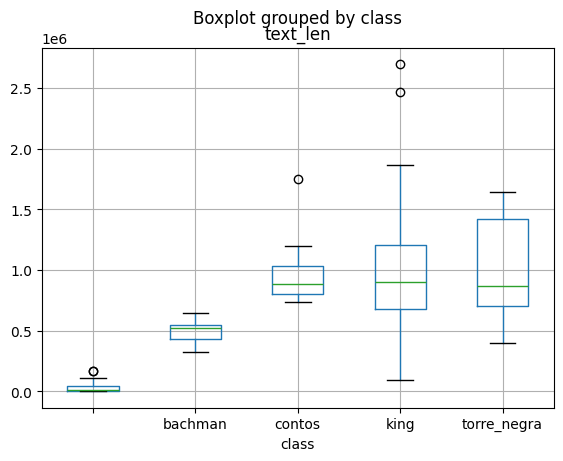

In [7]:
# Make a boxplot of text_len by author
import matplotlib.pyplot as plt

df_texts.boxplot(column="text_len", by="class")
plt.show()  

In [8]:
# Lendo e extraindo o livro coletanea novo do lovecraft
import ebooklib
from ebooklib import epub
from bs4 import BeautifulSoup

def epub_to_txt(epub_path, txt_path):
    book = epub.read_epub(epub_path)
    content = []
    for item in book.get_items():
        if item.get_type() == ebooklib.ITEM_DOCUMENT:
            soup = BeautifulSoup(item.get_content(), 'html.parser')
            text = soup.get_text()
            content.append(text)
    
    with open(txt_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(content))

epubs = list(Path("data/lovecraft_v3").glob("**/*.epub"))
epubs

[WindowsPath('data/lovecraft_v3/Howard Phillips Lovecraft - Os melhores Contos de H .P. Lovecraft--Volume 3 (2014, Saida De Emergência) - libgen.li.epub'),
 WindowsPath('data/lovecraft_v3/Lovecraft, H. P. - Os Horrores de Lovecraft (2018, Miskatonic) - libgen.li (1).epub'),
 WindowsPath('data/lovecraft_v3/Lovecraft, H. P. - Os Horrores de Lovecraft (2018, Miskatonic) - libgen.li.epub')]

In [9]:
# for file in epubs:
#     print(file)
#     txt_path = str(file).replace(".epub", " epub.txt").replace("lovecraft_v3", "lovecraft_txt_v3")
#     print(txt_path)
#     epub_to_txt(str(file), str(txt_path))

In [10]:
# Lendo livro completão
path_lovecraft_v3 = "data/lovecraft_txt_v3/Lovecraft, H. P. - Os Horrores de Lovecraft (2018, Miskatonic) - libgen.li epub.txt"
text_lovecraft_v3 = open(path_lovecraft_v3, "r", encoding="utf-8").read()
len(text_lovecraft_v3)

6129301

In [11]:
# Splitando em 16 quebras de linha
import re
texts_found = re.split("\n{16,}", text_lovecraft_v3)
print(len(texts_found))

171


In [12]:
# Loop de extração de títulos
titles = []
subtitles = []
texts = []

for i, t in enumerate(texts_found):
    try:
        title_sep = re.search("\n{6}∴", t, flags=re.MULTILINE)
        title = t[:title_sep.end()]
        title, subtitle = title.split("\n", maxsplit=1)
        subtitle = re.sub("\n{2,}|∴", "", subtitle, flags=re.MULTILINE)
        # print(f"{title=} {subtitle=}")
        t_ = t[title_sep.end():]
        # print(f"{t_[:100]=}")
        text_match = re.search("\n{3,}", t_, flags=re.MULTILINE)
        if text_match is None:
            text_match = re.search("\n{2,}", t_, flags=re.MULTILINE)
        text = t_[text_match.end():]
        # print(f"{text[:100]=}")
        # print(f"{text[-100:]=}")
        # print()
        titles.append(title)
        subtitles.append(subtitle)
        texts.append(text)
    except Exception as e:
        print(i, e)
        print(f"{t[:100]=}")
        print(f"{t[-100:]=}")
        if i == 168:
            apendices = t
        print()
print(len(texts))

0 'NoneType' object has no attribute 'end'
t[:100]='Sumário\n\nPágina de título\nCréditos\nIntrodução\nCiclo de Cthulhu\nDagon\nO Depoimento de Randolph Carter'
t[-100:]='roll without aim,\nWhere they roll in their horror unheeded,\nWithout knowledge, or lustre, or name. *'

148 'NoneType' object has no attribute 'end'
t[:100]='Nota\nEsta seção é composta por 18 narrativas (contos, noveletas, romances e novelas) de autores cuja'
t[-100:]='Algernon Blackwood e Edgar Allan Poe. Algumas dessas peças são raras e outras inéditas em português.'

167 'NoneType' object has no attribute 'end'
t[:100]='Hastur\n\n\n“Eu me vi diante de nomes e termos que já tinha ouvido antes nos contextos mais hediondos —'
t[-100:]='mitologia suméria e os mitos de Lovecraft. O nome “Cthulhu” foi puramente uma invenção de Lovecraft.'

168 'NoneType' object has no attribute 'end'
t[:100]='Rascunho descartado de\n‘A Sombra em Innsmouth’\n\n[pp. 1–6:]\nFoi no verão de 1927 que interrompi, subi'
t[-100:]=' cristal,\nt

In [13]:
# Extraindo apêndices também
import re
apps_found = re.split("\n{11,}", apendices)
print(len(apps_found))

12


In [14]:
titles2 = []
subtitles2 = []
texts2 = []

for i, t in enumerate(apps_found):
    try:
        title_sep = re.search("\n{2,}", t, flags=re.MULTILINE)
        title = t[:title_sep.end()]
        title, subtitle = title.split("\n", maxsplit=1)
        subtitle = re.sub("\n", " ", subtitle, flags=re.MULTILINE).strip()
        print(f"{i=} {title=} {subtitle=}")
        t_ = t[title_sep.end():]
        text = t_.strip("\n")
        print(f"{text[:100]=}")
        print(f"{text[-100:]=}")
        print()
        titles2.append(title)
        subtitles2.append(subtitle)
        texts2.append(text)
    except Exception as e:
        print(i, e)
        print(f"{t[:100]=}")
        print(f"{t[-100:]=}")
        print()
print(len(texts2))

i=0 title='Rascunho descartado de' subtitle='‘A Sombra em Innsmouth’'
text[:100]='[pp. 1–6:]\nFoi no verão de 1927 que interrompi, subitamente, minha viagem turística pela Nova Inglat'
text[-100:]='sticas. Eu mal conseguiria, agora, questionar a ingênua credulidade do supersticioso Padre Iwanicki.'

i=1 title='A Torre Cilíndrica' subtitle='(fragmento de ideia de uma história, data desconhecida)'
text[:100]='“S. de Arkham é uma torre cilíndrica de pedra com telhado cônico — talvez 3,6 metros de largura e 6 '
text[-100:]='ixo — o nível do solo subiu um pouco. Não é vista há muito tempo, já que todo mundo evita a ravina.”'

i=2 title='Carta a Clark Ashton Smith' subtitle=''
text[:100]='27 de Novem.[1]\nCaro C.A.S.:\nRecebi a sua carta e a Overland com grande satisfação. Ainda não sei se'
text[-100:]='s. Boa parte do folclore sobre os sátiros é bizarra ao extremo — e lembra as “pessoinhas” de Machen.'

i=3 title='Carta a Robert E. Howard' subtitle=''
text[:100]='14 de agosto de 1930.[1]\nN

In [15]:
sumario_completo = """Introdução
Ciclo de Cthulhu
Dagon
O Depoimento de Randolph Carter
Nyarlathotep
A Cidade sem Nome
Azathoth
O Chamado de Cthulhu
O Modelo de Pickman
A História do Necronomicon
Os Sonhos na Casa da Bruxa
O Festival
O Horror de Dunwich
O Visitante das Trevas
Nas Montanhas da Loucura
A Coisa na Soleira da Porta
A Sombra Vinda do Tempo
O Sabujo
A Sombra em Innsmouth
O Sussurro nas Trevas
A Cor que Caiu do Espaço
O Caso de Charles Dexter Ward
Ciclo dos Sonhos
O Navio Branco
Polaris
Memória
A Maldição de Sarnath
A Árvore
Os Gatos de Ulthar
Celephaïs
Ex Oblivione
A Busca de Iranon
Hipnos
O que a Lua Traz Consigo
A Estranha Casa na Neblina
A Chave de Prata
A Busca Onírica por Kadath
O Clérigo Maligno
O Intruso
Os Outros Deuses
Do Além
O Povo Antiquíssimo
O Inominável
Miscelânea
A Rua
O Medo à Espreita
A Música de Erich Zann
A Doce Ermengarda
Herbert West: Reanimador
A Tumba
O Templo
Ratos nas Paredes
Ele
O Horror em Red Hook
Na Catacumba
A Transição de Juan Romero
Fatos Acerca do Falecido Arthur Jermyn e sua Família
A Casa Temida
Ar Frio
O Descendente
O Livro
O Pântano Lunar
Além da Muralha do Sono
A Gravura na Velha Casa
O Velho Terrível
Old Bugs
Uma Reminiscência do Dr. Samuel Johnson
Ibid
Colaborações
O Desafio do Além
O Horror no Museu
A Maldição de Yig
O Rastejante Caos
A Colina
Vindo dos Éons
O Homem de Pedra
A Árvore na Colina
Através dos Portais da Chave de Prata
A Coisa no Luar
A Coisa com Focinho
Entre as Paredes de Eryx
Sob as Pirâmides
Poesia e os Deuses
A Feitiçaria de Aphlar
A Batalha que Encerrou o Século
O Oceano Noturno
Os Mortos Amados
O Diário de Alonzo Typer
A Morte do Monstro
Quatro Horas
O Horror em Martin’s Beach
O Último Teste
Cinzas
A Armadilha
Cosmos em Colapso
A Exumação
A Morte Alada
O Devorador de Fantasmas
O Tesouro da Besta-Mágica
O Executor Elétrico
O Horror no Cemitério
Tarbis do Lago
As Duas Garrafas Negras
Surdo, Mudo e Cego
As Tranças da Medusa
O Prado Verde
Até os Mares
Juvenília
A Pequena Garrafa de Vidro
O Mistério do Cemitério
A Caverna Secreta
O Navio Misterioso
O Navio Misterioso
A Fera na Caverna
O Alquimista
Poesias
Os Fungos de Yuggoth
Uma Elegia ao Dr. Franklin Chase Clark
Num Cemitério Retirado Onde Poe Caminhava Outrora
Fungos de Yuggoth
Tigrezinho
Nathicana
Festival
Astrophobos
O Mensageiro
A Cidade
Fato e Fantasia
Sobre a Vaidade da Ambição Humana
Unda; ou a Noiva do Mar
A Pã
Revelação
O Lago do Pesadelo
Desespero
O Conscrito
O Jardim
Ao Receber um Quadro com Cisnes
Os Gatos
Natal Egípcio
Nêmesis
A Klarkash-Ton, Senhor de Averoigne
Lembro-me
Época de Natal
Ao Pequeno Sam Perkins
Providence
À Dona Sofia Simple, Rainha do Cinema
[Tragam aqui, meus rapazes…]
A um Sonhador
Laeta; um Lamento
St. John
A Casa
A Clark Ashton Smith
Pôr do Sol
Dia das Bruxas num Subúrbio
Psychopompos; uma História em Versos
Extras
Nota
A Pedra Negra
O Errante das Estrelas
A Prole Inominável
Os Filhos da Noite
A Sombra do Campanário
Depoimento
O Pescador do Cabo do Falcão
Ubbo-Sathla
There are More Things
A Coisa no Telhado
O Retorno de Hastur
Cães de Tíndalos
O Fogo de Assurbanipal
Haïta, o Pastor
Um Habitante de Carcosa
Não Cavem Meu Túmulo
Os Salgueiros
A Narrativa de Arthur Gordon Pym
Bestiário
Hastur
Pinguins de Leng
Chaugnar Faugn
Tsathoggua
Ghouls
Gugs
Dagon
Yog-Sothoth
Shoggoths
Noctétricos
Rhan Tegoth
Antigos
Prole de Cthulhu
Grande Raça
Profundos
Mi-Go, os Fungos de Yuggoth
Nyarlathotep
Azathoth
Shub-Niggurath
Bestas lunares
Pólipos
Cthulhu
Apêndices
Rascunho descartado de ‘A Sombra em Innsmouth’
A Torre Cilíndrica (fragmento)
Carta a Clark Ashton Smith
Carta a Robert E. Howard
Carta a R. Michael
Carta a Robert E. Howard
Carta de Lovecraft a Zealia Bishop
Carta de Lovecraft a Wilfred B. Talman
Notas sobre a escritura de contos fantásticos
O horror sobrenatural em literatura
A última carta de HPL (fragmento)
A Howard Phillips Lovecraft"""

In [16]:
sumarios_completos = sumario_completo.split("\n")
len(sumarios_completos)

210

In [17]:
# Marcando tipo de documento usando o sumário
classes = []
classe = None
for i, t in enumerate(sumarios_completos):
    if t not in titles:
        classe = t
    else:
        classes.append(classe)
classes = classes[:len(titles)]

In [18]:
# Montando e preparando df
df_titles = pd.Series(titles, name="title").reset_index()
df_titles["class"] = classes
df_titles["subtitle"] = subtitles
df_titles["text"] = texts

In [19]:
df_apps = pd.Series(titles2, name="title").reset_index()
df_apps["class"] = "Apêndices"
df_apps["subtitle"] = subtitles2
df_apps["text"] = texts2

df_titles = pd.concat([df_titles, df_apps])

df_titles["author"] = "lovecraft"

In [20]:
df_titles["class"].value_counts()

class
Colaborações        38
Poesias             38
Miscelânea          24
Ciclo dos Sonhos    20
Ciclo de Cthulhu    20
Nota                18
Apêndices           12
Juvenília            7
Name: count, dtype: int64

In [21]:
df_full = pd.concat([df_texts, df_titles])
df_full["text"] = df_full["text"].str.strip()
df_full["text_start"] = df_full["text"].apply(lambda x: x[:30])
df_full["text_end"] = df_full["text"].apply(lambda x: x[-30:])
df_full["text_len"] = df_full["text"].str.len()
df_full["class"].value_counts()

class
                    52
king                47
Colaborações        38
Poesias             38
Miscelânea          24
Ciclo de Cthulhu    20
Ciclo dos Sonhos    20
Nota                18
contos              12
Apêndices           12
torre_negra          8
bachman              7
Juvenília            7
Name: count, dtype: int64

In [22]:
df_full = df_full[
    ['author', 'file', 'extension', 'class', 'title', 'subtitle', 'text_len', 'text_start', 'text_end', 'text']
]

In [23]:
df_full.sample(3).drop(columns='text')

,author,file,extension,class,title,subtitle,text_len,text_start,text_end
8,lovecraft,NaN,NaN,Apêndices,Notas sobre a escritura,de contos fantásticos,9648,Publicado postumamente em junh,m muito inferiores ao que são.
33,lovecraft,NaN,NaN,Ciclo dos Sonhos,A Busca Onírica por Kadath,,267206,Por três vezes Randolph Carter,avilhosa cidade ao pôr do sol.
109,lovecraft,NaN,NaN,Poesias,Os Fungos de Yuggoth,(Tradução de Nicolau Saião),26627,I. O livro\nO lugar era escuro,de 1929 – 4 de Janeiro de 1930


In [24]:
df_full.drop(columns="text").to_excel("df_full.xlsx")

In [25]:
from src.prep import clean_text

df_full["text_clean"] = df_full.text.apply(clean_text)

In [26]:
df_full[["author", "class"]].value_counts()

author     class           
lovecraft                      52
king       king                47
lovecraft  Colaborações        38
           Poesias             38
           Miscelânea          24
           Ciclo dos Sonhos    20
           Ciclo de Cthulhu    20
           Nota                18
king       contos              12
lovecraft  Apêndices           12
king       torre_negra          8
           bachman              7
lovecraft  Juvenília            7
Name: count, dtype: int64

In [27]:
# Marcando os textos a utilizar
df_full["train"] = (~df_full["class"].isin(['','Juvenília','Nota', 'Colaborações'])) & (df_full.extension!='mobi')

In [28]:
# Reordenando colunas
df_full = df_full[['train', 'author', 'file', 'extension', 'class', 'title', 'subtitle', 'text_len',
       'text_start', 'text_end', 'text', 'text_clean']]

In [33]:
df_full.file = df_full.file.apply(lambda x: str(x))

In [34]:
df_full.to_parquet("data/df_full_v0.pq")

In [35]:
df_full.query("train")[[
    "author", "class", "extension"]].value_counts(dropna=False).sort_index().reset_index()

,author,class,extension,count
0,king,bachman,epub,6
1,king,contos,epub,12
2,king,king,epub,38
3,king,king,pdf,2
4,king,torre_negra,epub,7
5,lovecraft,Apêndices,NaN,12
6,lovecraft,Ciclo de Cthulhu,NaN,20
7,lovecraft,Ciclo dos Sonhos,NaN,20
8,lovecraft,Miscelânea,NaN,24
9,lovecraft,Poesias,NaN,38


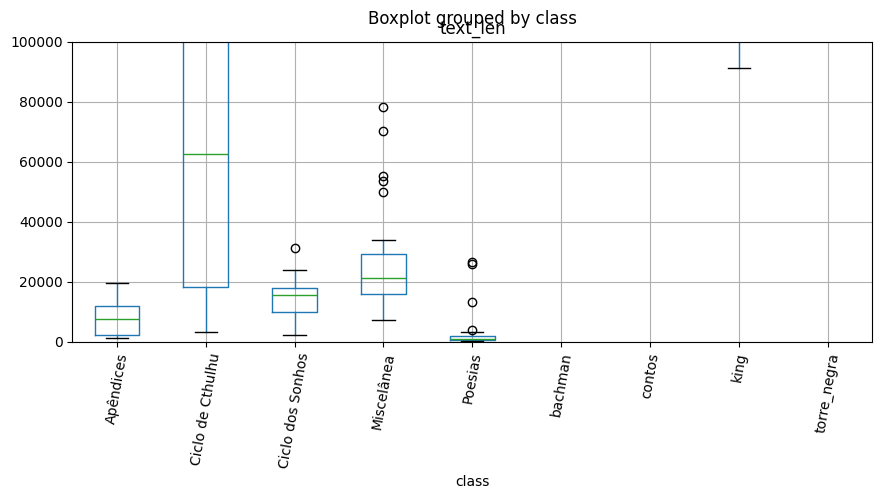

In [36]:
# Make a boxplot of text_len by author
import matplotlib.pyplot as plt

# limit y axis
df_full.query("train").boxplot(column="text_len", by="class", rot=80, figsize=(10, 4))
plt.ylim(0, 100_000)
plt.show()  

In [37]:
df_full.query("train").groupby("class")[["text_len"]].sum()

,text_len
class,
Apêndices,266681
Ciclo de Cthulhu,1717818
Ciclo dos Sonhos,534182
Miscelânea,664255
Poesias,107242
bachman,2806896
contos,11708622
king,38900587
torre_negra,6638883


# Testando Amostragem por texto

In [5]:
import pandas as pd
df_full = pd.read_parquet("data/df_full_v0.pq")

In [19]:
df_tokenizer = df_full[(~df_full["class"].isin([''])) & (df_full.extension!='mobi')].sample(frac=0.20, random_state=7)
df_tokenizer.value_counts(["author", "extension", "class"], dropna=False).sort_index().reset_index()

,author,extension,class,count
0,king,epub,bachman,2
1,king,epub,contos,3
2,king,epub,king,6
3,king,epub,torre_negra,1
4,lovecraft,NaN,Apêndices,3
5,lovecraft,NaN,Ciclo de Cthulhu,7
6,lovecraft,NaN,Ciclo dos Sonhos,5
7,lovecraft,NaN,Colaborações,5
8,lovecraft,NaN,Juvenília,1
9,lovecraft,NaN,Miscelânea,7


In [20]:
text_full = "\n\n\n".join(df_tokenizer.text_clean.to_list())
print(f"{len(text_full)=}")

len(text_full)=12366382


In [21]:
# save text_full
with open("data/tokenizer_mix_v1.txt", "w", encoding="utf-8") as f:
    f.write(text_full)

In [74]:
df_full.query("train").text

52    A AUTOESTRADA\nRoadwork\nStephen King(Richard ...
53    Stephen King\nA Longa Marcha\nTradução: Lia Wy...
54    STEPHEN KING\nescrito sob o pseudônimo de Rich...
55    STEPHEN KING\nEscrevendo Como \nRICHARD BACHMA...
56    Assim, como vocês veem,\nquando aumentamos o n...
                            ...                        
7     25 de Outubro de 1931\nA Wilfred Blanch Talman...
8     Publicado postumamente em junho de 1937 na Ama...
9     I. Introdução\nO medo é a emoção mais forte e ...
10    “No correr destes últimos tempos, muitos dos m...
11    Tu, que de montes, campos e cidades\nancestrai...
Name: text, Length: 179, dtype: object

In [ ]:
import torch
import re
import joblib
import pandas as pd
from tqdm import tqdm
tqdm.pandas()


class DataLoaderBpeV2:

    def __init__(
        self,
        context_len,
        batch_size,
        device,
        path_tokenizer="artifacts/tokenizers/mix_ptbr_4096_v1.joblib",
        path_input = "data/df_full_v0.pq",
        texts_sample_frac = 1.0,
        split_frac = 0.8,
    ):
        self.context_len = context_len
        self.batch_size = batch_size
        self.device = device
        self.split_frac = split_frac
        print(f"{context_len=}, {batch_size=}, {device=}, {split_frac=}")
        self.tokenizer = joblib.load(path_tokenizer)
        self.vocab_size_tokenizer = len(self.tokenizer.mergeable_ranks)
        print(f"{self.vocab_size_tokenizer=}")
        self.df_full = pd.read_parquet(path_input).query("train").sample(frac=texts_sample_frac, random_state=1).reset_index(drop=True)
        print(f"{self.df_full.shape=}")
        print(f"{self.df_full.value_counts(['author']).sort_index().reset_index()=}")
        print(f"{self.df_full.value_counts(['author','class']).sort_index().reset_index()=}")

    def load_data(self):
        print("load_data...")
        
        print(f"{self.df_full.shape}")
        text = "\n\n\n".join(self.df_full.text_clean.to_list())
        text = text[:1_000_000]
        print(f"{text[:2_000]=}")
        print(f"{len(text)=}")

        # here are all the unique characters that occur in this text
        chars = sorted(list(set(text)))
        print(f"{len(chars)=} {chars=}")

        tokens_full = self.tokenizer.encode(text, visualise=None)
        print(f"{len(tokens_full)=} {tokens_full[:300]=}")

        tokens = sorted(list(set(tokens_full)))
        print(f"{tokens=}")

        vocab_size_tokens = len(tokens)
        print(f"{vocab_size_tokens=}")
        estimated_starting_loss = -torch.log(torch.ones(1) / vocab_size_tokens).item()
        print(f"{estimated_starting_loss=}")

        vocab_size_tokenizer = len(self.tokenizer.mergeable_ranks)
        print(f"{vocab_size_tokenizer=}")
        estimated_starting_loss_ = -torch.log(torch.ones(1) / vocab_size_tokenizer).item()
        print(f"{estimated_starting_loss_=}")

        # encoder: take a string, output a list of integers
        encode = lambda s: self.tokenizer.encode(s, visualise=None)
        # decoder: take a list of integers, output a string
        decode = lambda l: self.tokenizer.decode(l)
        assert decode(encode("ola mundo ")) == "ola mundo "

        # Train and test splits
        self.df_full["text_encoded"] = self.df_full.text_clean.progress_apply(lambda x: torch.tensor(encode(x), dtype=torch.long))
        print(f"{self.df_full.text_encoded.apply(len).describe()=}")
        index_train = self.df_full.sample(frac=self.split_frac, random_state=1).index
        self.df_full["split"] = pd.Series(self.df_full.index.isin(index_train)).map({True: "train", False: "eval"})
        print(f"{self.df_full.value_counts(['split','author','class']).sort_index().reset_index()=}")

        self.encode = encode
        self.decode = decode

        return vocab_size_tokenizer, encode, decode

    def get_batch(self, split):
        # generate a small batch of data of inputs x and targets y
        df_split = self.df_full.query("split=='train'") if split == "train" else self.df_full.query("split=='eval'")
        df_batch = df_split.sample(self.batch_size, replace=True)

        x = torch.zeros((self.batch_size, self.context_len), dtype=torch.long)
        y = torch.zeros((self.batch_size, self.context_len), dtype=torch.long)
        for i, (id_row, row) in enumerate(df_batch.iterrows()):
            print(f"{i=} {id_row=} {row.author=} {row['class']=}{len(row.text_encoded)=}")
            t = row.text_encoded
            if len(t) <= self.context_len:
                t = torch.cat([t, torch.zeros(self.context_len, dtype=torch.long)])
                start_idx = 0
            else:
                start_idx = torch.randint(0, len(t) - self.context_len, (1,)).item()
            print(f"{len(t)=} {start_idx=} {start_idx + self.context_len=}")
            x[i] = t[start_idx : start_idx + self.context_len]
            y[i] = t[start_idx + 1 : start_idx + self.context_len + 1]

        x, y = x.to(self.device), y.to(self.device)
        return x, y


In [64]:
batch_size = 100  # independent sequences processed in parallel
context_len =  256  # maximum token context length
device = "cuda" if torch.cuda.is_available() else "cpu"
path_tokenizer = "artifacts/tokenizers/mix_ptbr_4096_v1.joblib"

data_loader = DataLoaderSimpleBpe(context_len, batch_size, device, path_tokenizer=path_tokenizer, texts_sample_frac=0.1)
vocab_size, encode, decode = data_loader.load_data()

context_len=256, batch_size=100, device='cuda', split_frac=0.8
self.vocab_size_tokenizer=4096
self.df_full.shape=(18, 12)
self.df_full.value_counts(['author']).sort_index().reset_index()=      author  count
0       king      6
1  lovecraft     12
self.df_full.value_counts(['author','class']).sort_index().reset_index()=      author             class  count
0       king           bachman      1
1       king            contos      2
2       king              king      3
3  lovecraft  Ciclo de Cthulhu      1
4  lovecraft  Ciclo dos Sonhos      2
5  lovecraft        Miscelânea      7
6  lovecraft           Poesias      2
load_data...
(18, 12)
text[:2_000]='Ha sacramentos do mal tanto quanto do bem a nossa volta, e nos vivemos e nos movimentamos, segundo a minha crenca, em um mundo desconhecido, um lugar onde ha cavernas, sombras e habitantes do crepusculo. E possivel que o homem possa algumas vezes retornar pela trilha da evolucao, e eu tenho a conviccao de que um saber terrivel ainda nao m

100%|██████████| 18/18 [00:17<00:00,  1.01it/s]

self.df_full.text_encoded.apply(len).describe()=count        18.000000
mean     131872.500000
std      219699.812463
min         624.000000
25%        4390.000000
50%       12077.500000
75%      226593.000000
max      764088.000000
Name: text_encoded, dtype: float64
self.df_full.value_counts(['split','author','class']).sort_index().reset_index()=   split     author             class  count
0   eval       king            contos      1
1   eval       king              king      1
2   eval  lovecraft        Miscelânea      2
3  train       king           bachman      1
4  train       king            contos      1
5  train       king              king      2
6  train  lovecraft  Ciclo de Cthulhu      1
7  train  lovecraft  Ciclo dos Sonhos      2
8  train  lovecraft        Miscelânea      5
9  train  lovecraft           Poesias      2


In [65]:
batch = data_loader.get_batch("train")
print(batch[0].shape)
batch[0]

i=0 id_row=1 row.author='lovecraft' row['class']='Ciclo dos Sonhos'len(row.text_encoded)=4276
len(t)=4276 start_idx=3661 start_idx + self.context_len=3917
i=1 id_row=7 row.author='king' row['class']='king'len(row.text_encoded)=764088
len(t)=764088 start_idx=746486 start_idx + self.context_len=746742
i=2 id_row=2 row.author='lovecraft' row['class']='Ciclo dos Sonhos'len(row.text_encoded)=8514
len(t)=8514 start_idx=3831 start_idx + self.context_len=4087
i=3 id_row=0 row.author='lovecraft' row['class']='Miscelânea'len(row.text_encoded)=15641
len(t)=15641 start_idx=9188 start_idx + self.context_len=9444
i=4 id_row=15 row.author='lovecraft' row['class']='Poesias'len(row.text_encoded)=624
len(t)=624 start_idx=69 start_idx + self.context_len=325
i=5 id_row=6 row.author='lovecraft' row['class']='Miscelânea'len(row.text_encoded)=5683
len(t)=5683 start_idx=1796 start_idx + self.context_len=2052
i=6 id_row=9 row.author='lovecraft' row['class']='Miscelânea'len(row.text_encoded)=2040
len(t)=2040 st

tensor([[ 147,   89, 1505,  ..., 1836,  177,  138],
        [ 653,  463,   93,  ..., 1544,  696,   14],
        [ 481,  342, 2335,  ...,   93,  567, 1793],
        ...,
        [ 776, 2966, 1546,  ...,  831,  133,  392],
        [1123,  891,   97,  ...,  249,  324,   89],
        [3107,   93,  345,  ...,  416,  130,  129]], device='cuda:0')

In [49]:
batch[1].shape

torch.Size([100, 256])